In [2]:
from matplotlib.ticker import PercentFormatter

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, Dropout ,Input, GlobalAveragePooling2D
from keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from keras.optimizers import SGD, Adam
from keras import layers
from keras.applications import ResNet50

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
def plot_conf_matrix(cm, class_names):
    ''' Plots a confusion matrix coming from the compute_classification_metrics function

    Args:
        - cm: confusion matrix.
    Returns:
        - Plot of the confusion matrix.

    '''
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.show()

In [4]:
def compute_classification_metrics(y_true, y_pred, class_names):
    '''Computes confusion matrix based on prediction and true labels.

    Args:
        - y_true (np.array): true labels of a dataset.
        - y_pred (np.array): predicted labels.
        - class_names (list): index-ordered class names.

    Returns:
        - cm: confusion matrix.
        - Also prints a classification report.

    '''
    cm = confusion_matrix(y_true, y_pred)
    str_summary = classification_report(y_true, y_pred, target_names=class_names)
    print(str_summary)

    # todo: manually compute other metrics
    return cm

In [5]:
def load_full_dataset(paths, labels, image_size):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda x, y: preprocess_image(x, y, image_size),
            num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(1024)

    images = []
    targets = []

    for batch_images, batch_labels in ds:
        images.append(batch_images)
        targets.append(batch_labels)

    X = tf.concat(images, axis=0)
    y = tf.concat(targets, axis=0)

    return X, y

In [6]:
def load_params(run_logdir):
    '''Loads a dictionary previously saved.

    Args:
        - run_logdir (str): path of the pickle file to be loaded.

    Returns:
        - loaded_params (dict): loaded dictionary.

    '''
    with open(run_logdir, 'rb') as f:
        loaded_params = pickle.load(f)

    return loaded_params

In [7]:
def preprocess_image(file_path, label, image_size):
    ''' Reads a file and then converts the input bytes using the appropiate scale into a Tensor.

    Args:
        - file_path (str): directory address where the file is.
        - label (str): real label of the original image.
        - image_size (tuple): global tuple indicating the original size of the image.

    Returns:
        - img: correspondent tensor of the converted image.
        - tf.one_hot(...): one-hot tensor of the original label

    '''
    img = tf.io.read_file(file_path)
    # by default we read it on RGB
    # img = tf.image.decode_image(img, channels=3)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, image_size)
    return img, tf.one_hot(label, depth=num_classes)

In [8]:
num_classes = 10

# Notes

- The execution of this notebook relies on previously generated files, specifically:

    - Data that has already been imported using the Kaggle API

    - A dictionary containing the optimal hyperparameters obtained during   the tuning phase

- All three components are imported from the GitHub repository, where the main code for each part was originally developed. This notebook focuses primarily on testing and evaluation in order to improve efficiency, avoiding the need to rerun the entire workflow.

# Cloning the repository

Since we need everything mentioned before from the repo, we clone it here in the notebook instance so we can execute the code

In [9]:
!git clone https://github.com/ffaundezcab/amd_garbage_recognizer

fatal: destination path 'amd_garbage_recognizer' already exists and is not an empty directory.


In [10]:
!pwd

/content


In [11]:
cd amd_garbage_recognizer

/content/amd_garbage_recognizer


In [12]:
ls

cardboard.png                LICENSE                     paper_sample.png
confusion_matrix_mobile.png  mobile_curve_plot.png       README.md
custom_curves_accuracy.png   mobile_curves_accuracy.png  sample_photos.png
custom_curves_plot.png       notebooks/                  scripts/
data/                        output.png


# Training-Validation curves

These plots come from training each model using their optimal hyperparameters and over the validation set. The purpose for this is to analyze the evolution during training, and estimate the generalization capacity.

Each model was executed 15 times to get average results for accuracy and validation, since each run is independent from another because of the initialization of the weights.

## Custom model

In [13]:
custom_logs = []

for i in range(1, 16):
    dft = pd.read_csv(f"notebooks/logs/custom/curves_data_{i}.csv")
    dft["run"] = i
    custom_logs.append(dft)

In [14]:
custom_df = pd.concat(custom_logs)
mean_metrics = custom_df.groupby("Unnamed: 0").mean()

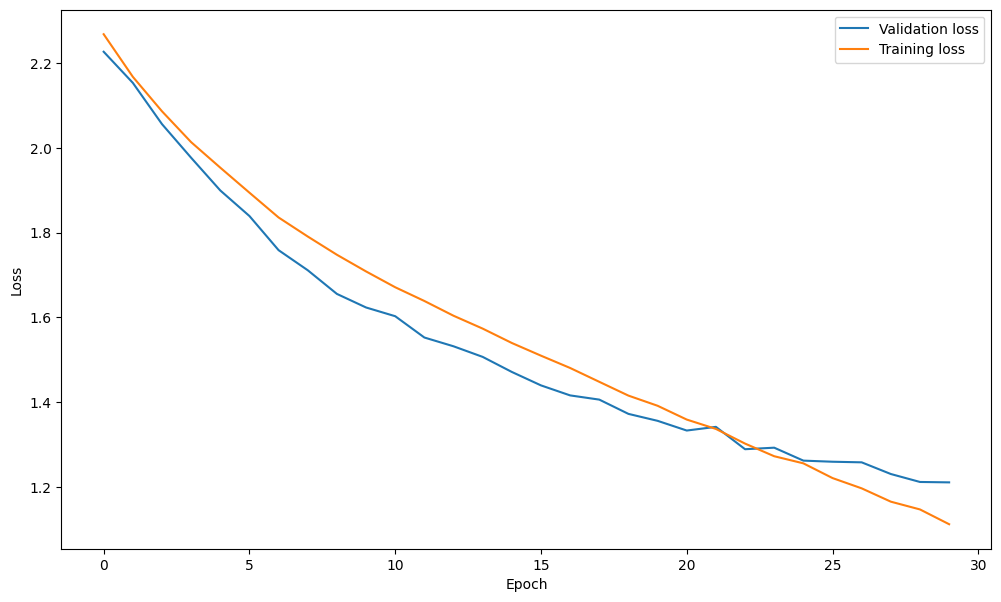

In [15]:
plt.figure(figsize=(12, 7))

ax = sns.lineplot(mean_metrics["val_loss"], label = "Validation loss")
ax2 = sns.lineplot(mean_metrics["loss"], label = "Training loss")

ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.legend(fontsize = 10)
plt.show()

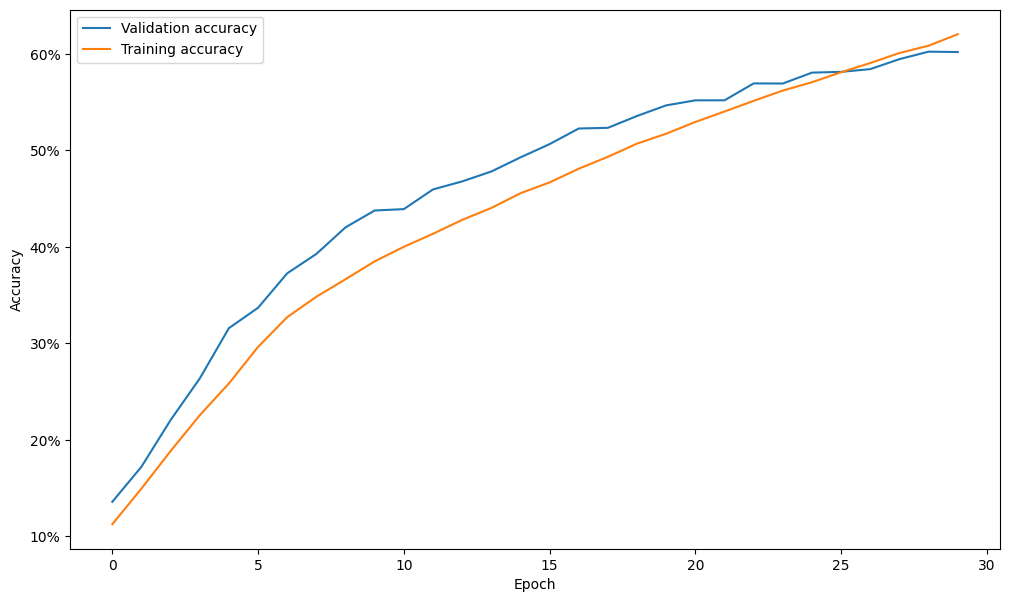

In [16]:
plt.figure(figsize=(12, 7))

ax = sns.lineplot(mean_metrics["val_accuracy"], label = "Validation accuracy")
ax2 = sns.lineplot(mean_metrics["accuracy"], label = "Training accuracy")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Epoch")

ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.legend(fontsize = 10)
plt.show()

## MobileNetV2

In [17]:
mobile_logs = []

for i in range(1, 16):
    dft = pd.read_csv(f"notebooks/logs/mobilenetv2/curves_data_{i}.csv")
    dft["run"] = i
    mobile_logs.append(dft)

In [18]:
mobile_df = pd.concat(mobile_logs)
mean_metrics = mobile_df.groupby("Unnamed: 0").mean()

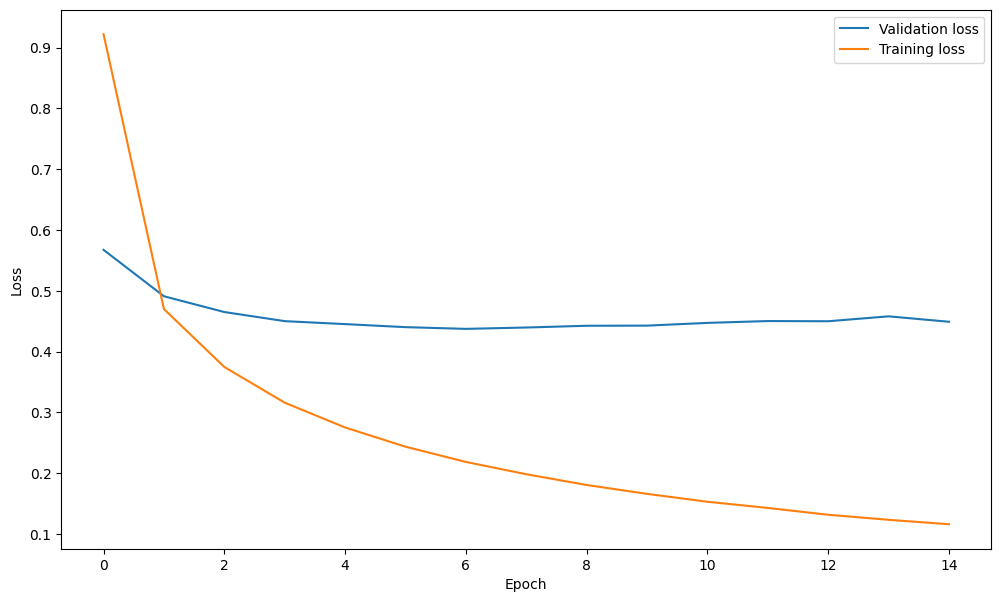

In [19]:
plt.figure(figsize=(12, 7))

ax = sns.lineplot(mean_metrics["val_loss"], label = "Validation loss")
ax2 = sns.lineplot(mean_metrics["loss"], label = "Training loss")

ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.legend(fontsize = 10)
plt.show()

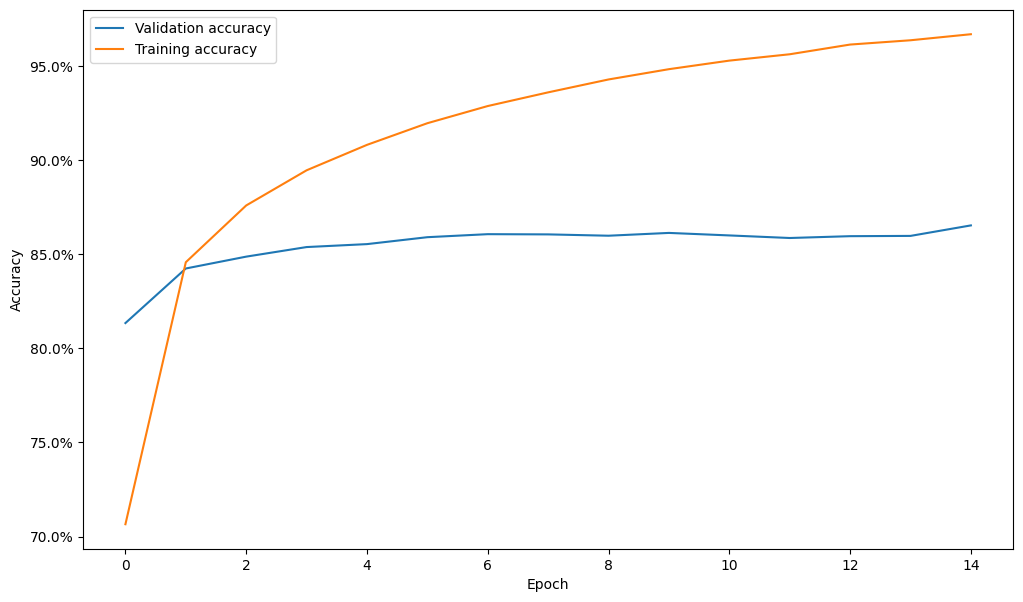

In [20]:
plt.figure(figsize=(12, 7))

ax = sns.lineplot(mean_metrics["val_accuracy"], label = "Validation accuracy")
ax2 = sns.lineplot(mean_metrics["accuracy"], label = "Training accuracy")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Epoch")

ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.legend(fontsize = 10)
plt.show()

# Test results

In [21]:
def read_split_data(which_model = "baseline", data_dir = "data/original", batch_size = 64):
  # change depending on which model
  if which_model == "baseline":
    image_size = (32, 32)
  else:
    image_size = (96, 96)

  file_paths = []
  labels = []

  # the name of each folder corresponds to the label of the images within
  class_names = os.listdir(data_dir)
  class_to_index = {name: i for i, name in enumerate(class_names)}

  # for each folder, we'll save the path of each file with its correspondent label
  for class_name in class_names:
      class_dir = f"{data_dir}/{class_name}"
      images = sorted(os.listdir(class_dir))
      for img_path in images:
          file_paths.append(class_dir + "/" + str(img_path))
          labels.append(class_to_index[class_name])

  # now we have all the paths and labels together
  file_paths = np.array(file_paths)


  # split
  labels = np.array(labels)
  dimension = 3

  X_train, X_test, y_train, y_test = train_test_split(
      file_paths,
      labels,
      test_size=0.15,
      stratify=labels,
      random_state=42
  )

  class_weights = compute_class_weight(
      class_weight="balanced",
      classes=np.unique(y_train),
      y=y_train
  )

  class_weights = dict(enumerate(class_weights))

  X_train_full, y_train_full = load_full_dataset(X_train, y_train, image_size)
  X_train_full = X_train_full.numpy().astype(int).squeeze()
  y_train_labels = np.argmax(y_train_full.numpy(), axis = 1)

  X_test_full, y_test_full = load_full_dataset(X_test, y_test, image_size)
  X_test_full = X_test_full.numpy().astype(int).squeeze()
  y_test_labels = np.argmax(y_test_full.numpy(), axis = 1)

  return X_train_full, y_train_labels,X_test_full, y_test_labels, class_weights, class_names


## Baseline

In [42]:
def build_custom_model(n_filters = 128, n_neurons = 64, learning_rate = 1e-2, dropout_rate = 0.5,
                      kernel_size = 3, pool_size = 2, beta_2 = 0.99, sparse = True, momentum = 0.9, image_size = (32,32) ,**kwargs):
    '''
    '''

    normalization_layer = Rescaling(1./255)

    model = Sequential([
    Input(shape = (image_size[0], image_size[1], 3)),
    normalization_layer,
    Conv2D(n_filters, kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    Conv2D(int(n_filters*2), kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    GlobalAveragePooling2D(),
    Dense(n_neurons, activation="relu"),
    Dropout(dropout_rate),
    Dense(int(n_neurons/2), activation="relu"),
    Dropout(dropout_rate),
    Dense(10, activation = "softmax")
                    ])

    # for the first model only SGD optimizer is used.
    optimizer = Adam(learning_rate=learning_rate, beta_1=momentum, beta_2=beta_2)

    loss = "categorical_crossentropy"
    if sparse:
        loss = "sparse_categorical_crossentropy"
    model.compile(loss = loss,
        optimizer = optimizer,
        metrics = ["accuracy"])

    return model

In [48]:
batch_size = 64
X_train_full, y_train_labels, X_test_full, y_test_labels, class_weights, class_names = read_split_data(which_model = "baseline", data_dir = "data/original", batch_size = batch_size)

In [39]:
# Best params for custom model
best_params = load_params("notebooks/logs/custom/custom_model")

# Build model with params
model = build_custom_model(**best_params)

# Fit custom model
model.fit(X_train_full, y_train_labels,
            epochs=30, verbose = 1,
            class_weight=class_weights,
            batch_size=batch_size)

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.1228 - loss: 2.2485
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1639 - loss: 2.1444
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.2077 - loss: 2.0513
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2591 - loss: 1.9629
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.2984 - loss: 1.8776
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3381 - loss: 1.8224
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3492 - loss: 1.7668
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3832 - loss: 1.7070
Epoch 9/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3975 - loss: 1.6743
Epoch 10/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4179 - loss: 1.6170
Epoch 11/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4414 - loss: 1.5782
Epoch 12/30
178/178 ━━━━━━━━━━━━━━━━━━━━

In [44]:
model.evaluate(X_test_full, y_test_labels)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6281 - loss: 1.1342


[1.1341749429702759, 0.6280578970909119]

In [45]:
y_pred = np.argmax(model.predict(X_test_full), axis = 1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [49]:
cm = compute_classification_metrics(y_test_labels, y_pred, class_names=class_names)

              precision    recall  f1-score   support

       trash       0.41      0.55      0.47        74
       paper       0.51      0.62      0.56       207
     clothes       0.77      0.83      0.80       298
   cardboard       0.66      0.71      0.68       230
     battery       0.81      0.68      0.74       122
       glass       0.91      0.44      0.60       300
  biological       0.75      0.75      0.75       122
     plastic       0.49      0.55      0.52       256
       shoes       0.80      0.57      0.67       245
       metal       0.36      0.60      0.45       149

    accuracy                           0.63      2003
   macro avg       0.65      0.63      0.62      2003
weighted avg       0.68      0.63      0.63      2003



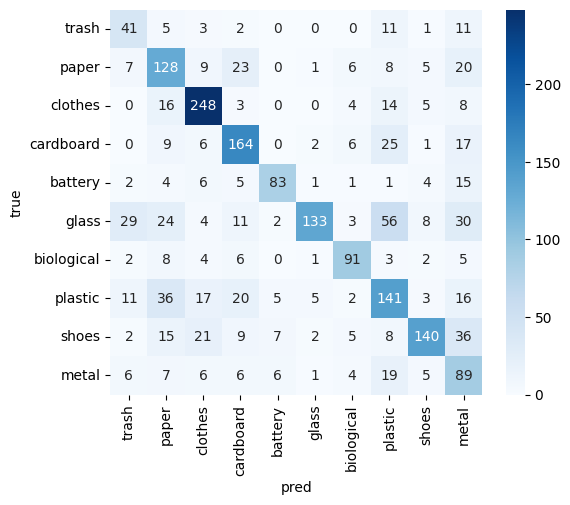

In [50]:
plot_conf_matrix(cm, class_names=class_names)

## MobileNetV2

In [22]:
batch_size = 64
X_train_full, y_train_labels, X_test_full, y_test_labels, class_weights, class_names = read_split_data(which_model = "mobilenet", data_dir = "data/original", batch_size = batch_size)

In [23]:
def build_MobileNetV2(learning_rate = 1e-2, momentum = 0.9, beta_2 = 0.99, **kwargs):

    normalization_layer = Rescaling(1./255)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    model = tf.keras.models.Sequential([normalization_layer,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation="softmax")
    ])

    optimizer = Adam(learning_rate=learning_rate, beta_1=momentum, beta_2=beta_2)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [24]:
best_params = load_params("notebooks/logs/mobilenetv2/mobilenetv2_model")
model = build_MobileNetV2(**best_params)

model.fit(X_train_full, y_train_labels,
            epochs=15, verbose = 1,
            class_weight=class_weights,
            batch_size=batch_size)

Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 34s 79ms/step - accuracy: 0.7184 - loss: 0.8901
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8509 - loss: 0.4614
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8776 - loss: 0.3738
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8971 - loss: 0.3168
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9073 - loss: 0.2808
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9192 - loss: 0.2502
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9272 - loss: 0.2264
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9322 - loss: 0.2056
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9388 - loss: 0.1889
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9438 - loss: 0.1759
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9504 - loss: 0.1639
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━

In [25]:
model.evaluate(X_test_full, y_test_labels)

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 182ms/step - accuracy: 0.8692 - loss: 0.4173


[0.4172954559326172, 0.8691961765289307]

In [26]:
y_pred = np.argmax(model.predict(X_test_full), axis = 1)
cm = compute_classification_metrics(y_test_labels, y_pred, class_names=class_names)

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step
              precision    recall  f1-score   support

       trash       0.71      0.73      0.72        74
       paper       0.78      0.77      0.77       207
     clothes       0.95      0.95      0.95       298
   cardboard       0.84      0.85      0.85       230
     battery       0.88      0.94      0.91       122
       glass       0.89      0.88      0.88       300
  biological       0.94      0.98      0.96       122
     plastic       0.80      0.79      0.79       256
       shoes       0.96      0.95      0.95       245
       metal       0.81      0.79      0.80       149

    accuracy                           0.87      2003
   macro avg       0.86      0.86      0.86      2003
weighted avg       0.87      0.87      0.87      2003



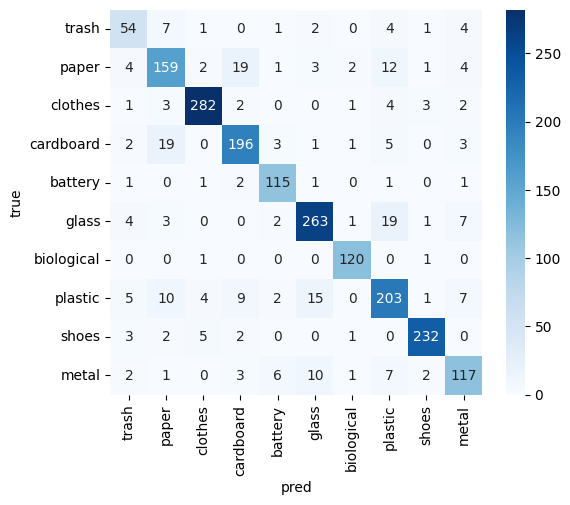

In [27]:
plot_conf_matrix(cm, class_names=class_names)